# CardioRisk ML
## 10-Year Cardiovascular Disease Risk Prediction

### Models
- Logistic Regression
- Random Forest

### Dataset
Framingham Cardiovascular Disease Dataset

### Objective
To predict the likelihood of developing coronary heart disease (CHD)
within 10 years using patient demographic and clinical risk factors.

In [39]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [40]:
# Load the dataset

df = pd.read_csv("framingham_heart_disease.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (4238, 16)


In [41]:
# Initial dataset inspection

print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

Shape: (4238, 16)

Column names:
['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']

First 5 rows:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 

In [42]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


In [43]:
# Target variable distribution

print("TenYearCHD distribution:")
print(df["TenYearCHD"].value_counts())

print("\nPercentage distribution:")
print(df["TenYearCHD"].value_counts(normalize=True) * 100)

TenYearCHD distribution:
TenYearCHD
0    3594
1     644
Name: count, dtype: int64

Percentage distribution:
TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64


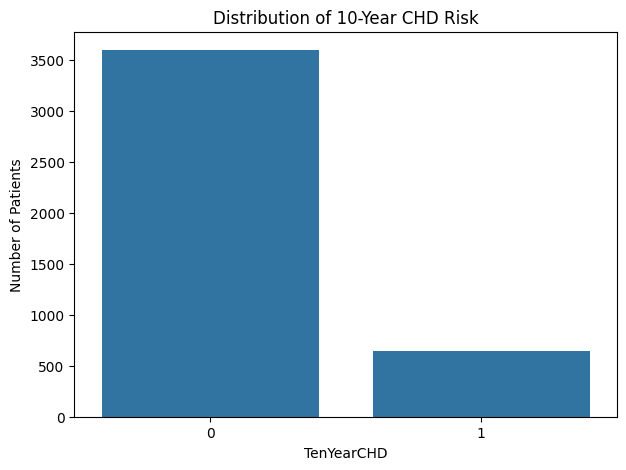

In [44]:
# Target distribution visualization

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="TenYearCHD")

plt.title("Distribution of 10-Year CHD Risk")
plt.xlabel("TenYearCHD")
plt.ylabel("Number of Patients")

plt.show()

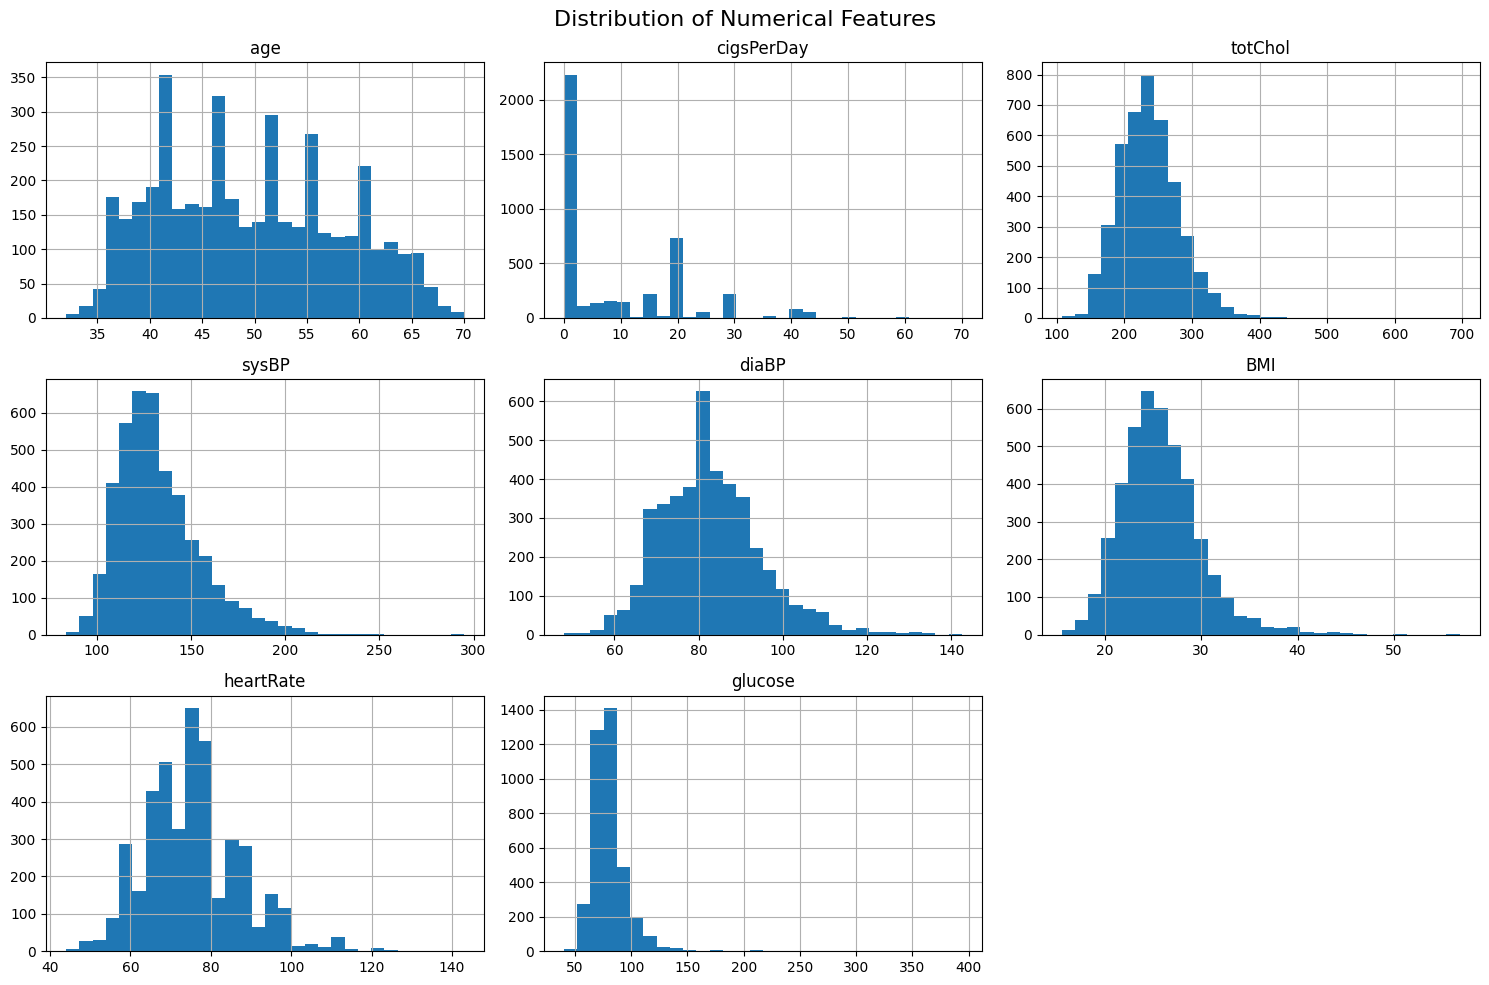

In [45]:
# Distribution of numerical features

numerical_features = [
    "age",
    "cigsPerDay",
    "totChol",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose"
]

df[numerical_features].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

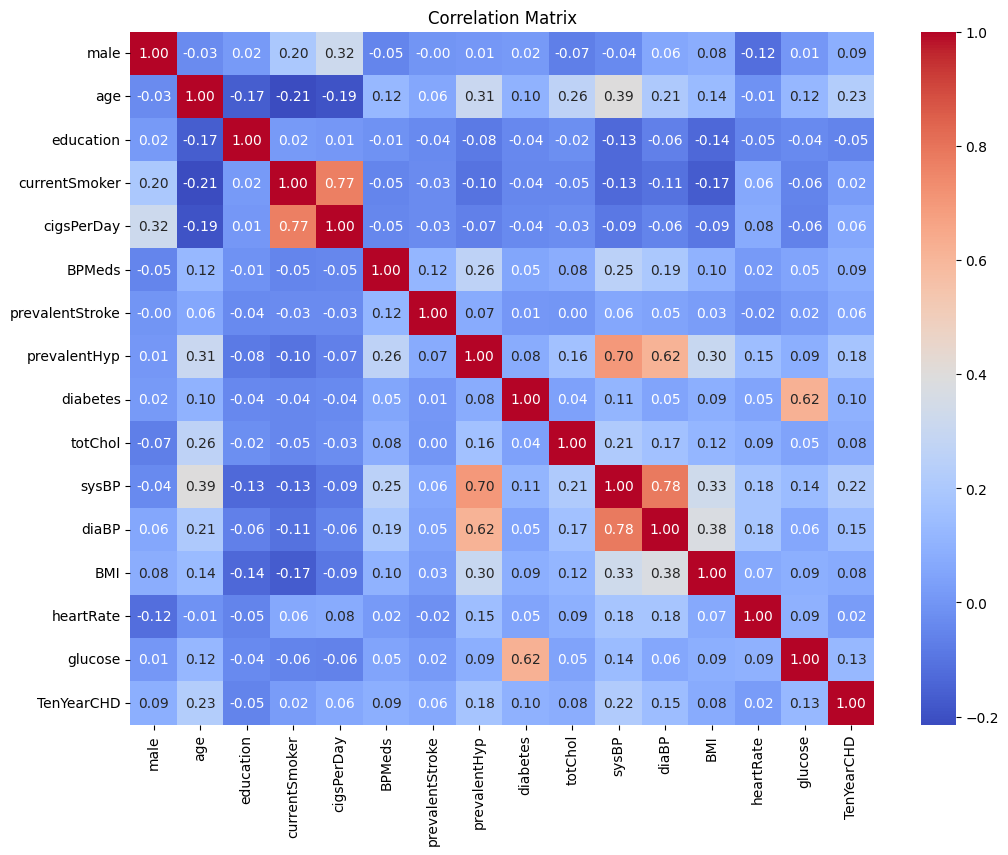

In [46]:
# Correlation matrix

plt.figure(figsize=(12, 9))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

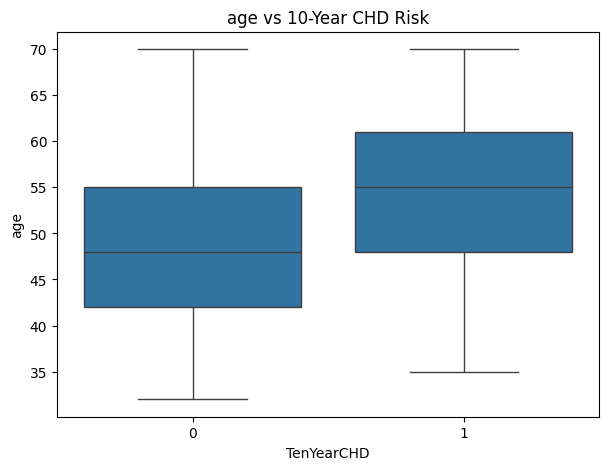

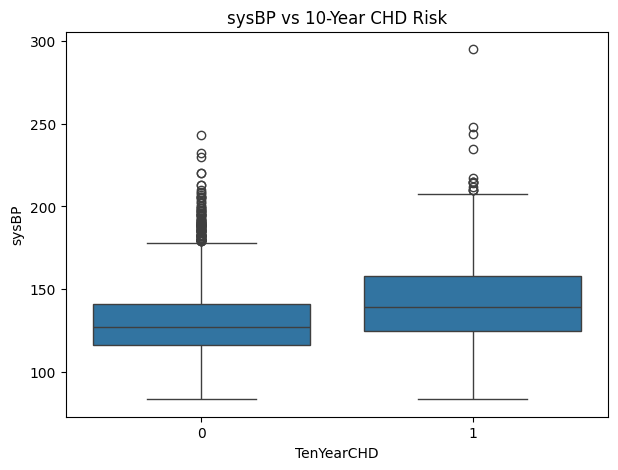

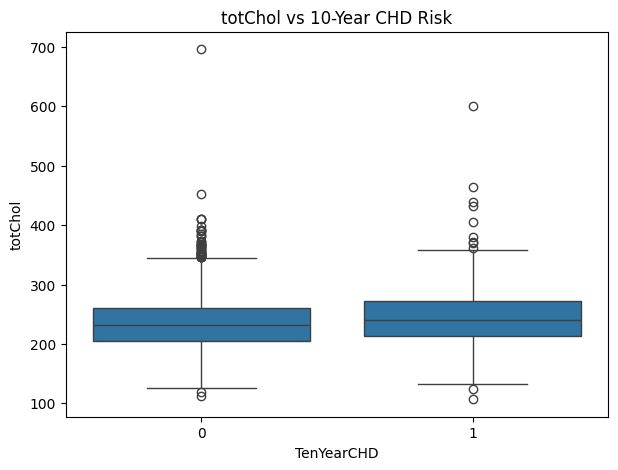

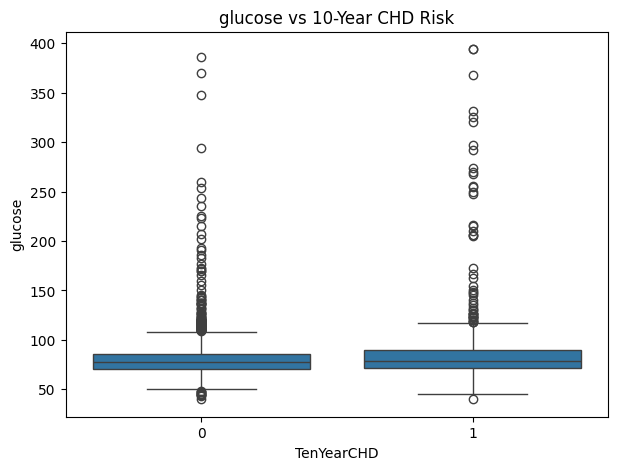

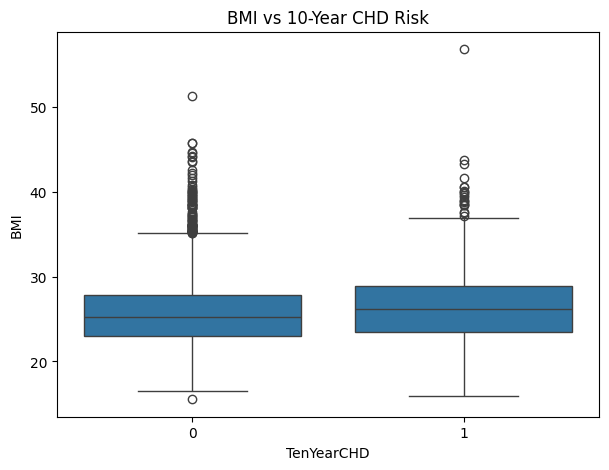

In [47]:
# Compare important numerical features by TenYearCHD

features_to_compare = [
    "age",
    "sysBP",
    "totChol",
    "glucose",
    "BMI"
]

for feature in features_to_compare:
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="TenYearCHD",
        y=feature
    )

    plt.title(f"{feature} vs 10-Year CHD Risk")
    plt.xlabel("TenYearCHD")
    plt.ylabel(feature)

    plt.show()

In [48]:
# Separate features and target

X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4238, 15)
Target shape: (4238,)


In [49]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# Stratify keeps the same proportion of positive/negative cases
# in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (3390, 15)
Testing set: (848, 15)

Training target distribution:
TenYearCHD
0    84.80826
1    15.19174
Name: proportion, dtype: float64

Testing target distribution:
TenYearCHD
0    84.787736
1    15.212264
Name: proportion, dtype: float64


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Numerical + ordinal features
numerical_features = [
    "age",
    "education",
    "cigsPerDay",
    "totChol",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose"
]

# Binary features
binary_features = [
    "male",
    "currentSmoker",
    "BPMeds",
    "prevalentStroke",
    "prevalentHyp",
    "diabetes"
]

print("Numerical features:", len(numerical_features))
print("Categorical/binary features:", len(binary_features))
print("Total:", len(numerical_features) + len(binary_features))

Numerical features: 9
Categorical/binary features: 6
Total: 15


In [51]:
# Preprocessing for Logistic Regression

numeric_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lr, numerical_features),
        ("binary", binary_transformer, binary_features)
    ]
)

print("Logistic Regression preprocessing pipeline created!")

Logistic Regression preprocessing pipeline created!


In [52]:
# Preprocessing for Random Forest
# Scaling is not required for tree-based models.

numeric_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, numerical_features),
        ("binary", binary_transformer, binary_features)
    ]
)

print("Random Forest preprocessing pipeline created!")

Random Forest preprocessing pipeline created!


In [53]:
# Training Logistic Regression and Random Forest models
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Logistic Regression...")
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

print("\nTraining Random Forest...")
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed!")

Training Logistic Regression...
Logistic Regression training completed!

Training Random Forest...
Random Forest training completed!


In [54]:
# Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Function to calculate specificity
def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)


# Logistic Regression predictions
lr_pred = logistic_model.predict(X_test)
lr_prob = logistic_model.predict_proba(X_test)[:, 1]


# Random Forest predictions
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]


# Metrics for Logistic Regression
lr_metrics = {
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred, zero_division=0),
    "Recall": recall_score(y_test, lr_pred, zero_division=0),
    "Specificity": calculate_specificity(y_test, lr_pred),
    "F1-Score": f1_score(y_test, lr_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, lr_prob),
    "PR-AUC": average_precision_score(y_test, lr_prob)
}


# Metrics for Random Forest
rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, zero_division=0),
    "Recall": recall_score(y_test, rf_pred, zero_division=0),
    "Specificity": calculate_specificity(y_test, rf_pred),
    "F1-Score": f1_score(y_test, rf_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, rf_prob),
    "PR-AUC": average_precision_score(y_test, rf_prob)
}


# Final comparison table
results = pd.DataFrame(
    [lr_metrics, rf_metrics],
    index=["Logistic Regression", "Random Forest"]
)

print("MODEL PERFORMANCE")
print("=" * 100)

display(results.round(4))

MODEL PERFORMANCE


,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC,PR-AUC
Logistic Regression,0.8491,0.5294,0.0698,0.9889,0.1233,0.6996,0.2971
Random Forest,0.8432,0.3000,0.0233,0.9903,0.0432,0.6479,0.2302


<Figure size 500x400 with 0 Axes>

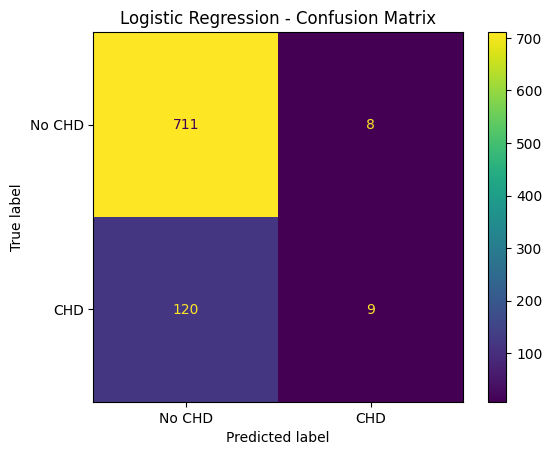

<Figure size 500x400 with 0 Axes>

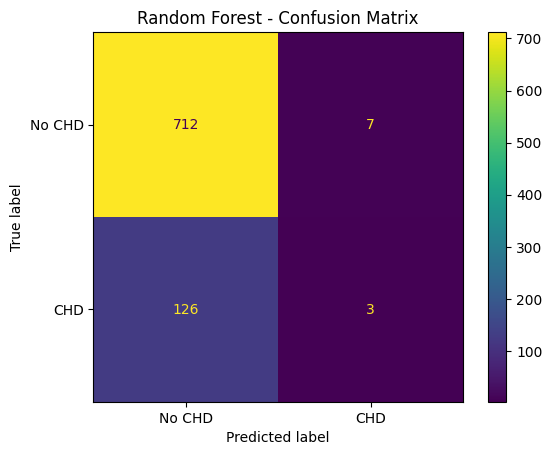

In [55]:
#confusion matrices
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic Regression
plt.figure(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["No CHD", "CHD"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# Random Forest
plt.figure(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["No CHD", "CHD"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [56]:
from sklearn.metrics import classification_report
print("LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(
    y_test,
    lr_pred,
    target_names=["No CHD", "CHD"],
    zero_division=0
))


print("\nRANDOM FOREST")
print("=" * 60)
print(classification_report(
    y_test,
    rf_pred,
    target_names=["No CHD", "CHD"],
    zero_division=0
))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

      No CHD       0.86      0.99      0.92       719
         CHD       0.53      0.07      0.12       129

    accuracy                           0.85       848
   macro avg       0.69      0.53      0.52       848
weighted avg       0.81      0.85      0.80       848


RANDOM FOREST
              precision    recall  f1-score   support

      No CHD       0.85      0.99      0.91       719
         CHD       0.30      0.02      0.04       129

    accuracy                           0.84       848
   macro avg       0.57      0.51      0.48       848
weighted avg       0.77      0.84      0.78       848



In [57]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression pipeline
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Parameters to test
lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"]
}

# Grid search
lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Tuning Logistic Regression...")

lr_grid.fit(X_train, y_train)

print("Logistic Regression tuning completed!")
print("\nBest parameters:")
print(lr_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(round(lr_grid.best_score_, 4))

Tuning Logistic Regression...
Logistic Regression tuning completed!

Best parameters:
{'classifier__C': 0.01, 'classifier__class_weight': 'balanced'}

Best CV ROC-AUC:
0.7331


In [58]:
# Random Forest pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# Parameters to test
rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 15],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__class_weight": [None, "balanced"]
}

# Grid search
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Tuning Random Forest...")

rf_grid.fit(X_train, y_train)

print("Random Forest tuning completed!")
print("\nBest parameters:")
print(rf_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(round(rf_grid.best_score_, 4))

Tuning Random Forest...
Random Forest tuning completed!

Best parameters:
{'classifier__class_weight': None, 'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}

Best CV ROC-AUC:
0.7229


In [59]:
# Evaluating tuned models on test set

best_lr_model = lr_grid.best_estimator_
best_rf_model = rf_grid.best_estimator_

# Predictions
tuned_lr_pred = best_lr_model.predict(X_test)
tuned_lr_prob = best_lr_model.predict_proba(X_test)[:, 1]

tuned_rf_pred = best_rf_model.predict(X_test)
tuned_rf_prob = best_rf_model.predict_proba(X_test)[:, 1]


# Tuned Logistic Regression metrics
tuned_lr_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_lr_pred),
    "Precision": precision_score(y_test, tuned_lr_pred, zero_division=0),
    "Recall": recall_score(y_test, tuned_lr_pred, zero_division=0),
    "Specificity": calculate_specificity(y_test, tuned_lr_pred),
    "F1-Score": f1_score(y_test, tuned_lr_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, tuned_lr_prob),
    "PR-AUC": average_precision_score(y_test, tuned_lr_prob)
}


# Tuned Random Forest metrics
tuned_rf_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_rf_pred),
    "Precision": precision_score(y_test, tuned_rf_pred, zero_division=0),
    "Recall": recall_score(y_test, tuned_rf_pred, zero_division=0),
    "Specificity": calculate_specificity(y_test, tuned_rf_pred),
    "F1-Score": f1_score(y_test, tuned_rf_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, tuned_rf_prob),
    "PR-AUC": average_precision_score(y_test, tuned_rf_prob)
}


# Create comparison table
tuned_results = pd.DataFrame(
    [tuned_lr_metrics, tuned_rf_metrics],
    index=["Tuned Logistic Regression", "Tuned Random Forest"]
)

print("TUNED MODEL PERFORMANCE")
print("=" * 100)

display(tuned_results.round(4))

TUNED MODEL PERFORMANCE


,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC,PR-AUC
Tuned Logistic Regression,0.6604,0.2427,0.5814,0.6745,0.3425,0.6983,0.2799
Tuned Random Forest,0.8491,1.0000,0.0078,1.0000,0.0154,0.6856,0.2656


<Figure size 500x400 with 0 Axes>

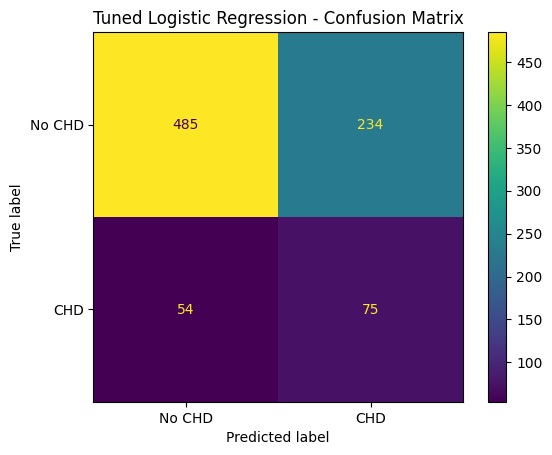

<Figure size 500x400 with 0 Axes>

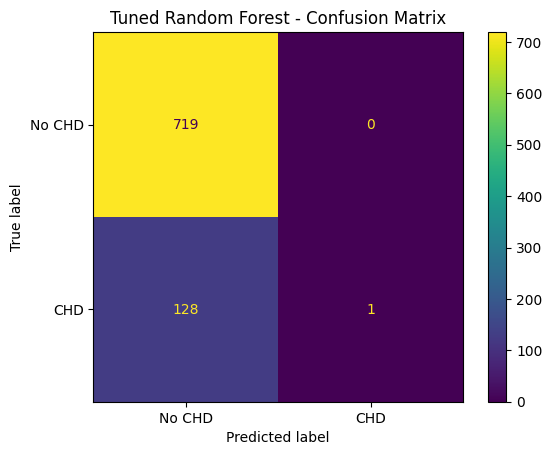

In [60]:
plt.figure(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_lr_pred,
    display_labels=["No CHD", "CHD"]
)

plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.show()

plt.figure(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_rf_pred,
    display_labels=["No CHD", "CHD"]
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

In [61]:
# threshold analysis using training data only

import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score

# Get out-of-fold probabilities for tuned Logistic Regression
lr_oof_prob = cross_val_predict(
    best_lr_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# Test different thresholds
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    oof_pred = (lr_oof_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_train,
            oof_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            oof_pred,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_train,
            oof_pred,
            zero_division=0
        )
    })


threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))


,Threshold,Precision,Recall,F1-Score
0,0.10,0.1520,1.0000,0.2638
1,0.15,0.1543,0.9961,0.2672
2,0.20,0.1610,0.9864,0.2768
3,0.25,0.1749,0.9631,0.2960
4,0.30,0.1901,0.9320,0.3158
5,0.35,0.2021,0.8816,0.3289
6,0.40,0.2252,0.8272,0.3540
7,0.45,0.2461,0.7592,0.3717
8,0.50,0.2716,0.6835,0.3887
9,0.55,0.2957,0.5748,0.3905


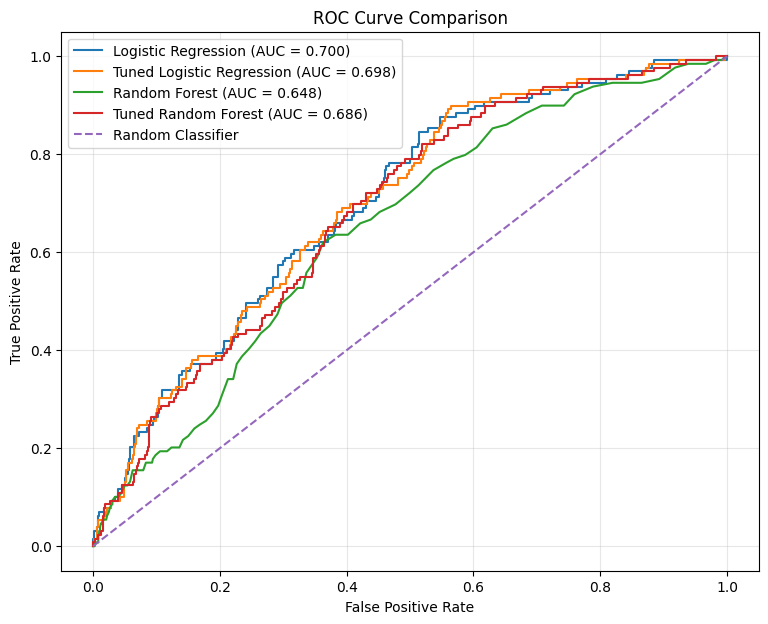

In [62]:
# ROC Curve

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
tuned_lr_fpr, tuned_lr_tpr, _ = roc_curve(y_test, tuned_lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
tuned_rf_fpr, tuned_rf_tpr, _ = roc_curve(y_test, tuned_rf_prob)

plt.figure(figsize=(9, 7))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    tuned_lr_fpr,
    tuned_lr_tpr,
    label=f"Tuned Logistic Regression (AUC = {tuned_lr_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    tuned_rf_fpr,
    tuned_rf_tpr,
    label=f"Tuned Random Forest (AUC = {tuned_rf_metrics['ROC-AUC']:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

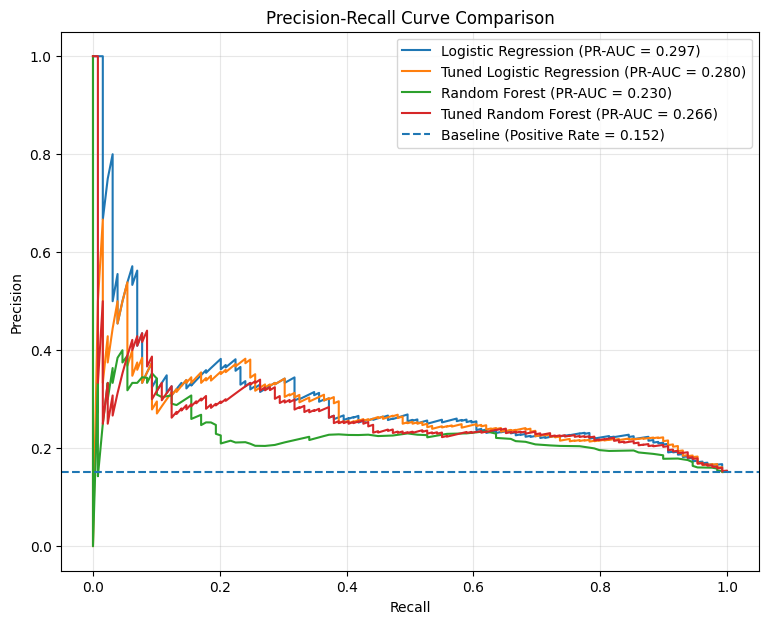

In [63]:
# Precision-Recall Curve

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate Precision-Recall curves
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_prob)
tuned_lr_precision, tuned_lr_recall, _ = precision_recall_curve(y_test, tuned_lr_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)
tuned_rf_precision, tuned_rf_recall, _ = precision_recall_curve(y_test, tuned_rf_prob)

# Plot
plt.figure(figsize=(9, 7))

plt.plot(
    lr_recall,
    lr_precision,
    label=f"Logistic Regression (PR-AUC = {lr_metrics['PR-AUC']:.3f})"
)

plt.plot(
    tuned_lr_recall,
    tuned_lr_precision,
    label=f"Tuned Logistic Regression (PR-AUC = {tuned_lr_metrics['PR-AUC']:.3f})"
)

plt.plot(
    rf_recall,
    rf_precision,
    label=f"Random Forest (PR-AUC = {rf_metrics['PR-AUC']:.3f})"
)

plt.plot(
    tuned_rf_recall,
    tuned_rf_precision,
    label=f"Tuned Random Forest (PR-AUC = {tuned_rf_metrics['PR-AUC']:.3f})"
)

# Baseline = positive class prevalence
baseline = y_test.mean()

plt.axhline(
    y=baseline,
    linestyle="--",
    label=f"Baseline (Positive Rate = {baseline:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [64]:
# Find threshold with highest F1-score

best_threshold_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best threshold:", best_threshold)
print("Precision:", round(best_threshold_row["Precision"], 4))
print("Recall:", round(best_threshold_row["Recall"], 4))
print("F1-Score:", round(best_threshold_row["F1-Score"], 4))

Best threshold: 0.5500000000000002
Precision: 0.2957
Recall: 0.5748
F1-Score: 0.3905


In [65]:
# Apply the threshold selected from training data

tuned_lr_threshold_pred = (
    tuned_lr_prob >= best_threshold
).astype(int)


# Evaluate
threshold_accuracy = accuracy_score(
    y_test,
    tuned_lr_threshold_pred
)

threshold_precision = precision_score(
    y_test,
    tuned_lr_threshold_pred,
    zero_division=0
)

threshold_recall = recall_score(
    y_test,
    tuned_lr_threshold_pred,
    zero_division=0
)

threshold_specificity = calculate_specificity(
    y_test,
    tuned_lr_threshold_pred
)

threshold_f1 = f1_score(
    y_test,
    tuned_lr_threshold_pred,
    zero_division=0
)

threshold_auc = roc_auc_score(
    y_test,
    tuned_lr_prob
)

threshold_pr_auc = average_precision_score(
    y_test,
    tuned_lr_prob
)


threshold_metrics = pd.DataFrame({
    "Accuracy": [threshold_accuracy],
    "Precision": [threshold_precision],
    "Recall": [threshold_recall],
    "Specificity": [threshold_specificity],
    "F1-Score": [threshold_f1],
    "ROC-AUC": [threshold_auc],
    "PR-AUC": [threshold_pr_auc]
}, index=["Tuned Logistic Regression + Optimized Threshold"])


display(threshold_metrics.round(4))

,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC,PR-AUC
Tuned Logistic Regression + Optimized Threshold,0.7158,0.2647,0.4884,0.7566,0.3433,0.6983,0.2799


In [66]:
#Get Feature Names

# Get the fitted preprocessing component
lr_preprocessor = best_lr_model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = lr_preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nFirst 15 features:")
print(feature_names[:15])

Number of processed features: 15

First 15 features:
['num__age' 'num__education' 'num__cigsPerDay' 'num__totChol' 'num__sysBP'
 'num__diaBP' 'num__BMI' 'num__heartRate' 'num__glucose' 'binary__male'
 'binary__currentSmoker' 'binary__BPMeds' 'binary__prevalentStroke'
 'binary__prevalentHyp' 'binary__diabetes']


In [67]:
#Logistic Regression Feature Importance

# Get Logistic Regression classifier
lr_classifier = best_lr_model.named_steps["classifier"]

# Get coefficients
lr_coefficients = lr_classifier.coef_[0]

# Creating feature importance table
lr_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_coefficients,
    "Absolute_Coefficient": np.abs(lr_coefficients)
})


lr_feature_importance = lr_feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("LOGISTIC REGRESSION FEATURE IMPORTANCE")
print("=" * 60)

display(lr_feature_importance.round(4))

LOGISTIC REGRESSION FEATURE IMPORTANCE


,Feature,Coefficient,Absolute_Coefficient
0,num__age,0.5248,0.5248
9,binary__male,0.2574,0.2574
2,num__cigsPerDay,0.2565,0.2565
4,num__sysBP,0.2484,0.2484
8,num__glucose,0.1430,0.1430
13,binary__prevalentHyp,0.1423,0.1423
11,binary__BPMeds,0.1064,0.1064
3,num__totChol,0.0936,0.0936
12,binary__prevalentStroke,0.0616,0.0616
14,binary__diabetes,0.0531,0.0531


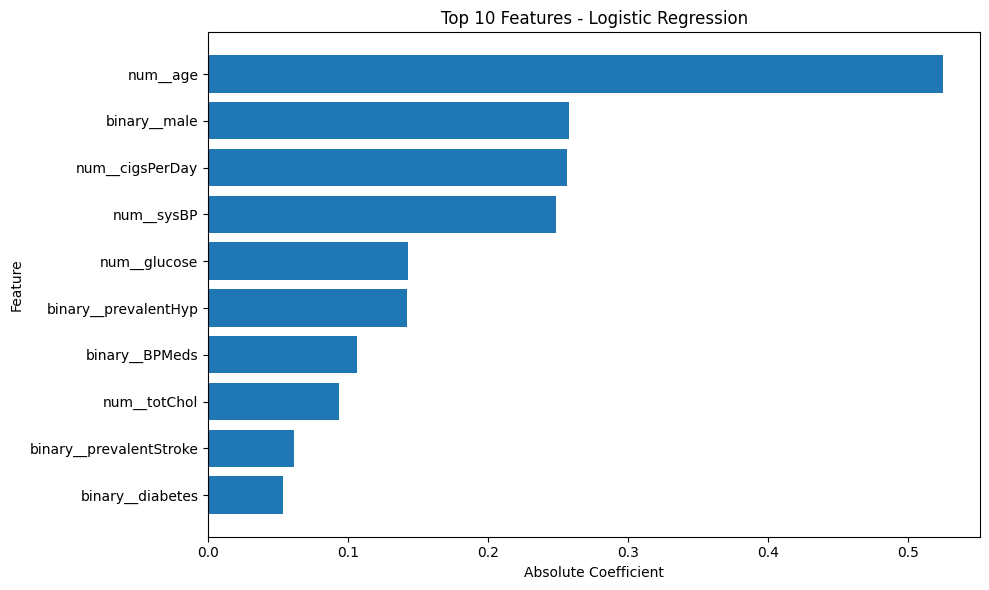

In [68]:
#ploting feature importance for logistic regression

top_lr_features = lr_feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_lr_features["Feature"][::-1],
    top_lr_features["Absolute_Coefficient"][::-1]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features - Logistic Regression")

plt.tight_layout()
plt.show()

In [69]:
# feature importance for random forest

# Get Random Forest classifier
rf_classifier = best_rf_model.named_steps["classifier"]


rf_importances = rf_classifier.feature_importances_


rf_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
})


rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

display(rf_feature_importance.round(4))

RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
0,num__age,0.2184
4,num__sysBP,0.1786
5,num__diaBP,0.1171
8,num__glucose,0.1046
3,num__totChol,0.0683
13,binary__prevalentHyp,0.0665
6,num__BMI,0.0625
2,num__cigsPerDay,0.0501
7,num__heartRate,0.0396
9,binary__male,0.0297


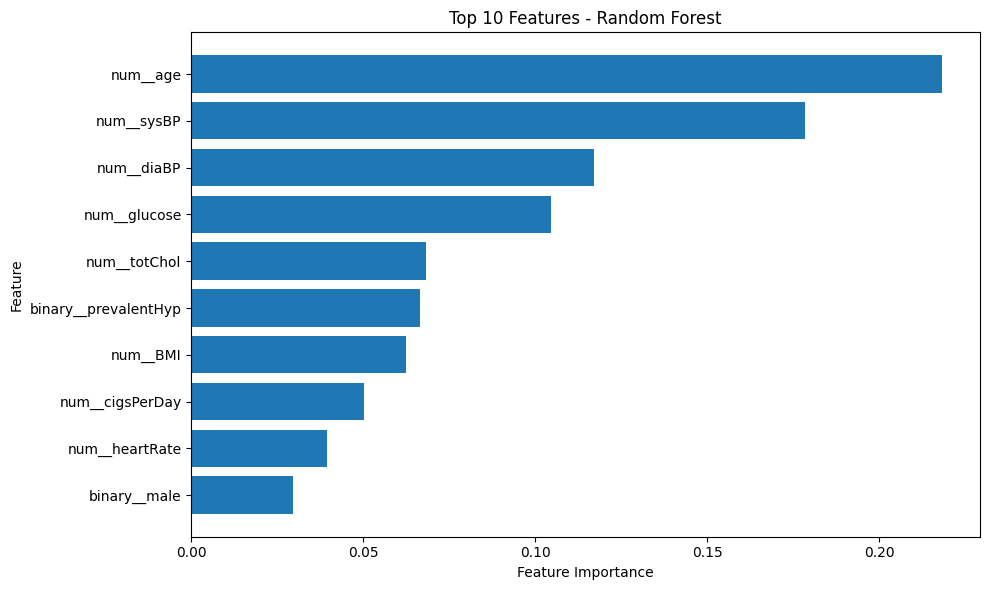

In [70]:
#plotting feature importance for random forest

top_rf_features = rf_feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rf_features["Feature"][::-1],
    top_rf_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features - Random Forest")

plt.tight_layout()
plt.show()

In [71]:
#Final Model Comparison

final_comparison = pd.DataFrame({
    "Original Logistic Regression": lr_metrics,
    "Tuned Logistic Regression": tuned_lr_metrics,
    "Tuned LR + Optimized Threshold": {
        "Accuracy": threshold_accuracy,
        "Precision": threshold_precision,
        "Recall": threshold_recall,
        "Specificity": threshold_specificity,
        "F1-Score": threshold_f1,
        "ROC-AUC": threshold_auc,
        "PR-AUC": threshold_pr_auc
    },
    "Original Random Forest": rf_metrics,
    "Tuned Random Forest": tuned_rf_metrics
}).T

print("FINAL MODEL COMPARISON")
print("=" * 80)

display(final_comparison.round(4))


FINAL MODEL COMPARISON


,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC,PR-AUC
Original Logistic Regression,0.8491,0.5294,0.0698,0.9889,0.1233,0.6996,0.2971
Tuned Logistic Regression,0.6604,0.2427,0.5814,0.6745,0.3425,0.6983,0.2799
Tuned LR + Optimized Threshold,0.7158,0.2647,0.4884,0.7566,0.3433,0.6983,0.2799
Original Random Forest,0.8432,0.3000,0.0233,0.9903,0.0432,0.6479,0.2302
Tuned Random Forest,0.8491,1.0000,0.0078,1.0000,0.0154,0.6856,0.2656


<Figure size 600x500 with 0 Axes>

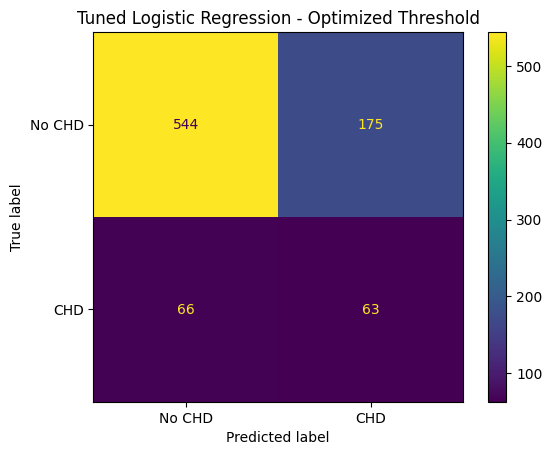

In [72]:
#Final Confusion Matrix

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_lr_threshold_pred,
    display_labels=["No CHD", "CHD"]
)

plt.title("Tuned Logistic Regression - Optimized Threshold")
plt.show()

In [73]:
import joblib

final_comparison.to_csv(
    "final_model_comparison.csv"
)

lr_feature_importance.to_csv(
    "logistic_regression_feature_importance.csv",
    index=False
)

rf_feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

# Save trained model pipelines
joblib.dump(best_lr_model, "logistic_regression_model.pkl")
joblib.dump(best_rf_model, "random_forest_model.pkl")

print("Results saved successfully!")


Results saved successfully!


In [74]:
# Example new patient
new_patient = pd.DataFrame({
    "age": [55],
    "education": [2],
    "cigsPerDay": [10],
    "totChol": [220],
    "sysBP": [140],
    "diaBP": [90],
    "BMI": [28.5],
    "heartRate": [75],
    "glucose": [100],
    "male": [1],
    "currentSmoker": [1],
    "BPMeds": [0],
    "prevalentStroke": [0],
    "prevalentHyp": [1],
    "diabetes": [0]
})

# Get probability from tuned Logistic Regression
new_probability = best_lr_model.predict_proba(new_patient)[0, 1]

# Apply the threshold we selected earlier
new_prediction = int(new_probability >= best_threshold)

print("Predicted CHD probability:", round(new_probability, 4))
print("Predicted CHD risk (%):", round(new_probability * 100, 2), "%")

if new_prediction == 1:
    print("Prediction: CHD")
else:
    print("Prediction: No CHD")

Predicted CHD probability: 0.6397
Predicted CHD risk (%): 63.97 %
Prediction: CHD
